# 👋🛎️ **Introduction** : Hilton Hotel Booking Cancellation Prediction

 ### **Business Problem:**

 This project aims to predict the status of hotel reservations at **Hilton Hotels** i.e., if it is **cancelled** or **not cancelled**. Hotel reservations are a crucial part of it's revenue flow and for it's efficient operations.


 ### **Importance:**
 Predicting booking cancellations can help the hotel to strategize overbooking, prevent revenue loss and maximizing confirmed booking rates.


 ### **Data Collection:**
The data is collected by the hotel's booking system.
This includes date of reservation, type of rooms, guest details like number of adults and accompanying children and some other time related booking details like lead time (days since booking to day of arrival), number of week and weekend nights, etc.


 ### **Machine Learning Formulation:**
This is a binary classification task with the objective to create a machine learning model that predicts the probability of the 'cancellation' and 'no cancellation' of the bookings at the hotel using the available features.


# 📑 **Imports**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn import metrics, compose, preprocessing
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

# 📥 **Data Loading**

The link to my dataset: https://www.kaggle.com/datasets/youssefaboelwafa/hotel-booking-cancellation-prediction/data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/booking.csv")
df.head()

,Booking_ID,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status
0,INN00001,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,10/2/2015,Not_Canceled
1,INN00002,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,11/6/2018,Not_Canceled
2,INN00003,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2/28/2018,Canceled
3,INN00004,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,5/20/2017,Canceled
4,INN00005,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,4/11/2018,Canceled


# 🕵️ **Data Exploration**

Checking the shape and datatypes in the DataFrame

In [ ]:
print(df.shape)
df.info()

(36285, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36285 entries, 0 to 36284
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Booking_ID                36285 non-null  object 
 1   number of adults          36285 non-null  int64  
 2   number of children        36285 non-null  int64  
 3   number of weekend nights  36285 non-null  int64  
 4   number of week nights     36285 non-null  int64  
 5   type of meal              36285 non-null  object 
 6   car parking space         36285 non-null  int64  
 7   room type                 36285 non-null  object 
 8   lead time                 36285 non-null  int64  
 9   market segment type       36285 non-null  object 
 10  repeated                  36285 non-null  int64  
 11  P-C                       36285 non-null  int64  
 12  P-not-C                   36285 non-null  int64  
 13  average price             36285 non-null  float64

Describe the DataFrame to check for data errors or inconsistencies.

In [ ]:
df.describe()

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests
count,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000,36285.000000
mean,1.844839,0.105360,0.810693,2.204602,0.030977,85.239851,0.025630,0.023343,0.153369,103.421636,0.619733
std,0.518813,0.402704,0.870590,1.410946,0.173258,85.938796,0.158032,0.368281,1.753931,35.086469,0.786262
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,1.000000,13.000000,58.000000,540.000000,5.000000


Checking for `null` values in the DataFrame:

In [ ]:
df.isnull().sum()

,0
Booking_ID,0
number of adults,0
number of children,0
number of weekend nights,0
number of week nights,0
type of meal,0
car parking space,0
room type,0
lead time,0
market segment type,0


No `null` data found in DataFrame. :)

Checking for duplicates

In [ ]:
print(df.duplicated().sum())

0


# 🫧 **Data Cleaning**

While converting `'date of reservation'` object type to datetime type, an error occurred where the below date could not be converted.

The error occurred as the date does not exist.

Below are the number of rows with the wrong date:

In [ ]:
df[df['date of reservation'] == '2018-2-29'].shape

(37, 17)

Hence, we will remove the rows with this date value in column `'date of reservation'` from the DataFrame.

In [ ]:
df = df[df['date of reservation'] != '2018-2-29']

In [ ]:
df[df['date of reservation'] == '2018-2-29'].shape

(0, 17)

# ⚙️ **Data Preprocessing and Feature Engineering**

Converted the `'date of reservation'` object type to datetime type so that I can extract the year, month and day.

In [ ]:
df['date of reservation'] = pd.to_datetime(df['date of reservation'],format='%m/%d/%Y')

In [ ]:
df["month"] = df["date of reservation"].dt.month
df["year"] = df['date of reservation'].dt.year
df["day"] = df["date of reservation"].dt.day

As the `'Booking ID'` is an identification feature, I will drop it from the DataFrame.

In [ ]:
df = df.drop(columns = ['Booking_ID'])
df.head()

,number of adults,number of children,number of weekend nights,number of week nights,type of meal,car parking space,room type,lead time,market segment type,repeated,P-C,P-not-C,average price,special requests,date of reservation,booking status,month,year,day
0,1,1,2,5,Meal Plan 1,0,Room_Type 1,224,Offline,0,0,0,88.00,0,2015-10-02,Not_Canceled,10,2015,2
1,1,0,1,3,Not Selected,0,Room_Type 1,5,Online,0,0,0,106.68,1,2018-11-06,Not_Canceled,11,2018,6
2,2,1,1,3,Meal Plan 1,0,Room_Type 1,1,Online,0,0,0,50.00,0,2018-02-28,Canceled,2,2018,28
3,1,0,0,2,Meal Plan 1,0,Room_Type 1,211,Online,0,0,0,100.00,1,2017-05-20,Canceled,5,2017,20
4,1,0,1,2,Not Selected,0,Room_Type 1,48,Online,0,0,0,77.00,0,2018-04-11,Canceled,4,2018,11


# ✂️ **Splitting the DataFrame**

We will split the DataFrame into train, validation and test for training the model, validating the model, making necessary iterations by evaluating and changing the parameters and, finally, testing the data against the model predictions.

In [ ]:
df_train, df_test = train_test_split(df, random_state = 42)
df_train, df_val = train_test_split(df_train, random_state = 42)

print('Shape of the DataFrame:', df.shape)
print('Shape of the train DataFrame:',df_train.shape)
print('Shape of the validation DataFrame:',df_val.shape)
print('Shape of the test DataFrame:',df_test.shape)

Shape of the DataFrame: (36248, 19)
Shape of the train DataFrame: (20389, 19)
Shape of the validation DataFrame: (6797, 19)
Shape of the test DataFrame: (9062, 19)


Creating `X` with all features without target `(booking status)` and `Y` with target feature.

In training dataset, this helps in model training.

In validation and test dataset, this helps with comparing the predictions to the actual target values.

In [ ]:
# X & Y train dataframe
x_train = df_train.drop("booking status", axis = 1)
y_train = df_train['booking status']

# X & Y validation dataframe
x_val = df_val.drop("booking status", axis = 1)
y_val = df_val['booking status']

# X & Y test dataframe
x_test = df_test.drop("booking status", axis = 1)
y_test = df_test['booking status']

print('Shape of the X train DataFrame:',x_train.shape)
print('Shape of the Y train DataFrame:',y_train.shape)
print('Shape of the X validation DataFrame:',x_val.shape)
print('Shape of the Y validation DataFrame:',y_val.shape)
print('Shape of the X test DataFrame:',x_test.shape)
print('Shape of the Y test DataFrame:',y_test.shape)

Shape of the X train DataFrame: (20389, 18)
Shape of the Y train DataFrame: (20389,)
Shape of the X validation DataFrame: (6797, 18)
Shape of the Y validation DataFrame: (6797,)
Shape of the X test DataFrame: (9062, 18)
Shape of the Y test DataFrame: (9062,)


# ❕ **Removing Outlier**

Z-Score was used to calculate and remove outliers from my numeric features.

A threshold of 3 was used to identify and remove outliers.

But removing outliers **negatively impacted** my model accuracy, hence, the decision made was to keep all values from the features of the dataset.

# ⚖️ **Scaling and Encoding**

Segregating the dataset into categorical and numerical features for encoding and scaling.

In [ ]:
categorical = x_train.select_dtypes(include=['object']).columns
numerical = x_train.select_dtypes(include=['int64','int32','float64']).columns

print(categorical)
print(numerical)

Index(['type of meal', 'room type', 'market segment type'], dtype='object')
Index(['number of adults', 'number of children', 'number of weekend nights',
       'number of week nights', 'car parking space', 'lead time', 'repeated',
       'P-C', 'P-not-C', 'average price', 'special requests', 'month', 'year',
       'day'],
      dtype='object')


Using `StandardScaler` to scale the **numerical** features and `OneHotEncoder` to encode the **categorical** features of the dataset using `ColumnTransformer`.

Then proceed to fit the `X` train, `X` validate, `X` test with the scaling and encoding.

In [ ]:
ct = compose.ColumnTransformer(
    [
      ("scaling", preprocessing.StandardScaler(), numerical),
      ("encoding", preprocessing.OneHotEncoder(handle_unknown="ignore"), categorical)
    ]
 )

ct.fit(x_train)
x_train = ct.transform(x_train)
x_val = ct.transform(x_val)
x_test = ct.transform(x_test)

print(x_train.shape)
print(y_train.shape)
print(x_val.shape)
print(y_val.shape)
print(x_test.shape)
print(y_test.shape)

(20389, 30)
(20389,)
(6797, 30)
(6797,)
(9062, 30)
(9062,)


It was attempted to train the models **without scaling of numerical values** but the model accuracy was **negatively** impacted.

# 🌲 **Random Forest**

**GridSearchCV** was finally used for hyperparameter tuning as it gave the **best parameters for RandomForest**.

RandomForest with the best parameters from GridSearchCV retrieved the best model accuracy.

The code for **GridSearchCV** and the model accuracy of **RandomForest** for the dataset are given below:

In [ ]:
# Random Forest classifier
randomforest_classifier = RandomForestClassifier(random_state = 42)

# Parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200, 300],            # Number of trees in forest
    'max_depth': [None, 10, 20, 30],            # Max depth of trees
    'min_samples_split': [2, 5, 10],            # Min number samples required to split  internal node
    'min_samples_leaf': [1, 2, 4],              # Min number samples required to be at leaf node
    'max_features': ['sqrt', 'log2'],           # Number of features to consider at every split
}

# Grid search with cross-validation
grid_search = GridSearchCV(estimator = randomforest_classifier, param_grid = param_grid,
                           cv = 5, n_jobs = -1, scoring ='accuracy')

# Fit grid search to training data
grid_search.fit(x_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best Score: 0.8955806704267999


In [ ]:
# Random Forest model
modelRF = RandomForestClassifier(max_depth = 20, max_features = 'sqrt', min_samples_leaf = 1,
                                 min_samples_split = 2, n_estimators = 300, random_state = 42)
# Fit model to training data
modelRF.fit(x_train, y_train)
# Predictions using validation set
y_predictedRF = modelRF.predict(x_val)

# Evaluate model's performance
accuracy_rf = accuracy_score(y_val, y_predictedRF)

In [ ]:
print('Model accuracy with RandomForest:', round(accuracy_rf * 100, 2), '%')

Model accuracy with RandomForest: 89.1 %


###The best accuracy of `89.1%`, was found using `RandomForest` model with best parameters from `GridSearchCV`.

### **Trail with other evaluation techniques for RandomForest:**

**RandomizedSearchCV** was used for hyperparameter tuning with 10 iterations giving best parameters for **RandomForest**. RandomForest with best parameters from RandomizedSearchCV gave an accuracy of `88.9%`.

### **Trails with other models:**

* **Optuna** was used for hyperparameter tuning with 10 trails giving best parameters for **GradientBoost**.
GradientBoost with best parameters from Optuna gave an accuracy of `88.7%`

* **BayesianOptimization** was used for hyperparameter tuning with 25 iterations giving best parameters for **Decision Tree**.
Decision Tree with best parameters from BayesianOptimization gave an accuracy of `86.7%`

* **KFold** was used for hyperparameter tuning giving best parameters for **KNN**.
KNN with best parameters from KFold gave an accuracy of `83.9%`

### **Confusion Matrix**

As this is a case of classification, we will use a confusion matrix to evaluate the performance of the classification model.

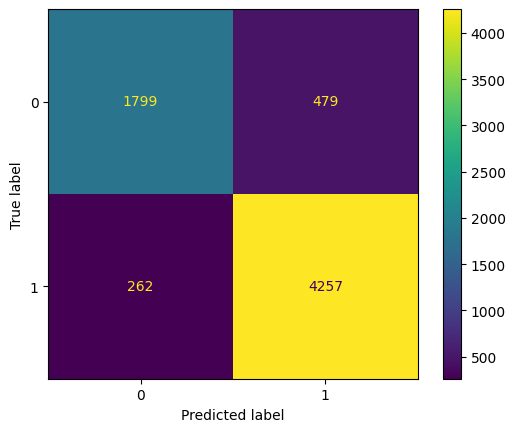

In [ ]:
# Confusion Matrix to evaluate model using visualization
confusion_matrix = metrics.confusion_matrix(y_val, y_predictedRF)

# Display the confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
# Plot the graph
cm_display.plot()
plt.show()

`0` represents **Cancelled**. `1` represents **Not Cancelled**.

* True Positives (**TP**): `1799`
* True Negatives (**TN**): `4257`
* False Positives (**FP**): `262`
* False Negatives (**FN**):  `479`

### **Feature Importance**

In [ ]:
# Retrieving feature importance of the model
fs = modelRF.feature_importances_
feature_names = df_train.columns

# Get feature names from the ColumnTransformer
feature_names = numerical.tolist() + ct.named_transformers_['encoding'].get_feature_names_out(categorical).tolist()

# Create DataFrame
pd.DataFrame(fs.reshape(1, -1), columns=feature_names) # Reshape fs to have 1 row and multiple columns

,number of adults,number of children,number of weekend nights,number of week nights,car parking space,lead time,repeated,P-C,P-not-C,average price,special requests,month,year,day,type of meal_Meal Plan 1,type of meal_Meal Plan 2,type of meal_Meal Plan 3,type of meal_Not Selected,room type_Room_Type 1,room type_Room_Type 2,room type_Room_Type 3,room type_Room_Type 4,room type_Room_Type 5,room type_Room_Type 6,room type_Room_Type 7,market segment type_Aviation,market segment type_Complementary,market segment type_Corporate,market segment type_Offline,market segment type_Online
0,0.025043,0.007195,0.034407,0.048624,0.007491,0.321444,0.002995,0.000476,0.001788,0.146373,0.116858,0.077707,0.027926,0.079693,0.008202,0.009777,1.890143e-08,0.005544,0.007315,0.002291,0.000029,0.006357,0.00189,0.00184,0.000484,0.00056,0.00068,0.005948,0.020448,0.030616


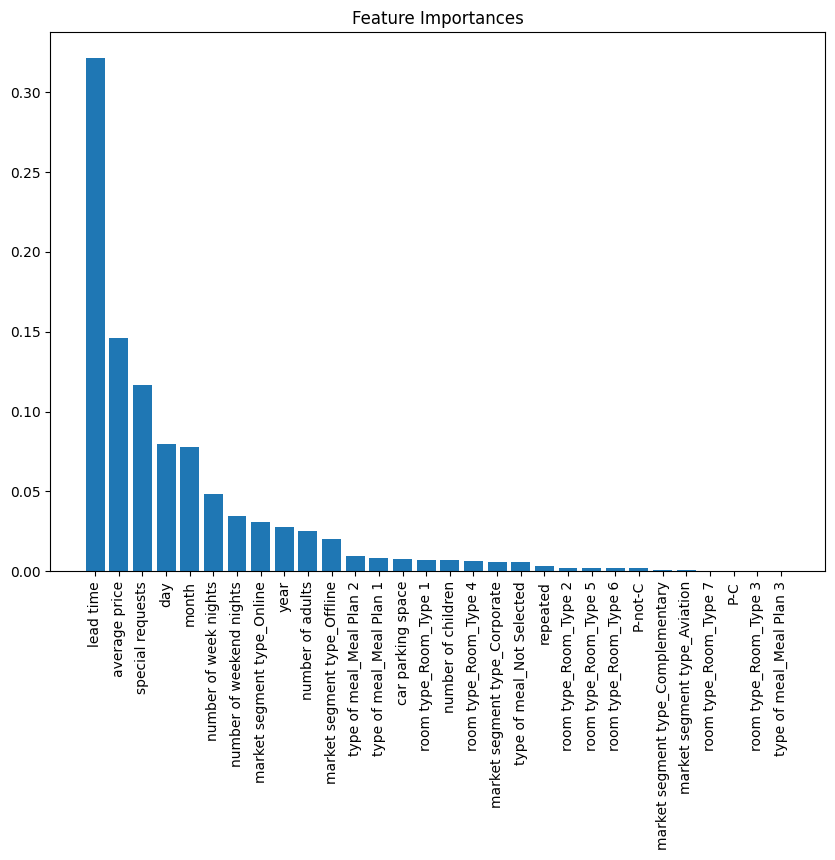

In [ ]:
# Plotting the graph
feature_importances = pd.DataFrame(fs,feature_names).sort_values(by=0,ascending=False)
plt.figure(figsize=(10, 7))
plt.title("Feature Importances")
plt.bar(x=feature_importances.index,height=feature_importances[0])
plt.xticks(rotation=90)
plt.show()

**Outputs from feature importance:**

- **Top Contributors**: The top features contributing to the the model's predictions are **lead time** (days between the booking date and the arrival date) , the **average price** of the stay and **special requests** that are made during booking, followed by the day and month.
- **Relative Importance**: Lead time is highly important compared to all other features with a high impact on prediction power.
- **Insights**: Higher or lower lead time highly impacts the rate of cancellation and specific marketing campaigns addressed to these customers could prevent the customers from cancelling their stay.
We also see that average pricing of the stay highly impacts the model performance. Hence, monitoring the price hikes while maintaining profits will prevent cancellation and will prevent losses.

# 🧪 **Model performance of Test set**

In [ ]:
y_predictedRF = modelRF.predict(x_test)
accuracy = accuracy_score(y_test, y_predictedRF)
print('Model accuracy with RandomForest:', round(accuracy * 100, 2), '%')

Model accuracy with RandomForest: 89.67 %


####The model accuracy on the test set is `89.67%`.

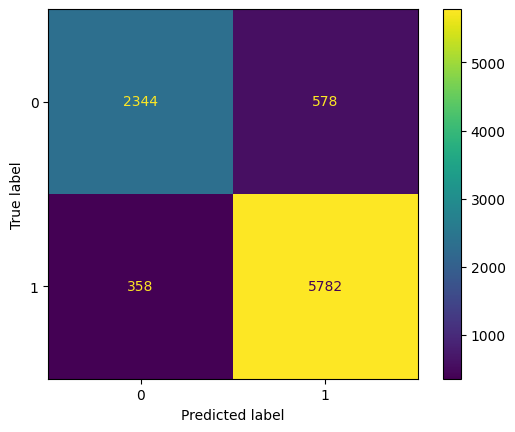

In [ ]:
# Confusion Matrix to evaluate model using visualization
confusion_matrix = metrics.confusion_matrix(y_test, y_predictedRF)

# Display the confusion matrix
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
# Plot the graph
cm_display.plot()
plt.show()

`0` represents **Cancelled**. `1` represents **Not Cancelled**.

* True Positives (**TP**): `2344`
* True Negatives (**TN**): `5782`
* False Positives (**FP**): `358`
* False Negatives (**FN**):  `578`

#🤔 **Final Discussion**


### **Overall Strengths and Limitations**
**Strengths:**
 * **High Accuracy:** The RandomForest Model scored a high accuracy of 89.67%.
 * **Robust Feature Engineering:** Relevant information was derived from 'date of reservation' using feature engineering, helping the model understand the date column and perform better.
 * **Hyperparameter Tuning:** GridSearchCV was used to gain the best hyperparameters, therefore gaining the best performance.
 * **Comprehensive Evaluation:** The model was evaluated on it's strength and weakness using confusion matrix.
 * **Feature Importance Analysis:** The most important and influencial features were visualized to understand the working and prioritizing of the model.


**Limitations:**
 * **Data Dependency:** The performance of the model is dependant on the quality of the training data.
 * **Potential Overfitting:** There is a risk of overfitting even after hyperparameter tuning in models like RandomForest.
 * **Limited Explainability:** RandomForest model are not easy to interpret and explain, because of complex working, compared to models like Decision Tree.

### **Implications for the Business Problem**


The model results imply that the model can predict hotel reservation cancellation status with a high accuracy, therefore improving revenue flow and overall efficiency:
 * **Strategic Overbooking:** To optimize the overbooking strategy, the models prediction can be used to identify cancellations to prevent loss.
 * **Resource Allocation:** Staff, rooms and amenities can be allocated efficiently based on foreseen cancellations by adjusting staff or optimal room assignments.
 * **Guest Satisfaction:** The hotel can improve guest satisfaction by minimizing overbooking inconveniences.


### **Data-Driven Recommendations**

Here are some recommendations based on the model results and feature importance analysis derived from the hotel data:

 * **Lead Time Management:** Offer incentives for early bookings or set clear expectations for last-minute reservations for guests with long or short lead times.
 * **Pricing Optimization:** Adjust prices dynamically to minimize cancellations while maintaining profit revenue.
 * **Special Requests Handling:** Fulfill special requests by guests as this impacts cancellation.
 * **Customer Segmentation:** Tailor marketing campaigns to customers based on their booking patterns to satisfy their needs, thereby decreasing cancellation.

### **Informative Features**

 Here are the top informative features of the model:
 1. **Lead Time:** Days between the booking date and arrival date.
 2. **Average Price:** The average price of the stay.
 3. **Special Requests:** Number of special requests made by the guest.
 4. **Reservation Date (Day and Month):** Day and month of the reservation date.

### **Model Explainability**

Even though RandomForest models are not easy to interpret and explain, we can still interpret some of it's working:
 * **Feature Importance:** The influencial features and their correlation to the target help us predict the cancellations accurately.
